<a href="https://colab.research.google.com/github/thazsobral/playstore-medallion-pipeline/blob/main/conception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Passo 0: Instalação e Configuração

Primeiro, precisamos instalar uma biblioteca que nos permita buscar dados da Play Store facilmente.

In [8]:
!pip install google-play-scraper

# Passo 1: EXTRACT (Extração)

Aqui, vamos buscar as avaliações de um aplicativo real (vamos usar o Duolingo como exemplo, mas pode ser qualquer um).

In [9]:
import os
import pandas as pd
from google_play_scraper import Sort, reviews

# Definindo constantes no início para facilitar a manutenção.
APP_ID = 'com.duolingo'
LANG = 'pt'
COUNTRY = 'br'
LIMIT = 500  # Quantidade de registros para o nosso poC

print(f"[*] Iniciando a extração de dados para o app: {APP_ID}...")

# Extraindo os dados da API
result, _ = reviews(
    APP_ID,
    lang=LANG,
    country=COUNTRY,
    sort=Sort.NEWEST,
    count=LIMIT
)

# Convertendo a lista de dicionários em um DataFrame do Pandas
df_raw = pd.DataFrame(result)

# Criando a pasta da camada Bronze
os.makedirs('data_lake/bronze', exist_ok=True)

# Salvando o dado BRUTO.
df_raw.to_json('data_lake/bronze/reviews_raw.json', orient='records', lines=True)

print("[✓] Fase de Extração concluída. Dados salvos na camada BRONZE.")

[*] Iniciando a extração de dados para o app: com.duolingo...
[✓] Fase de Extração concluída. Dados salvos na camada BRONZE.


**Por que JSON?**

Porque APIs respondem em formato semi-estruturado (JSON). Mantemos a fidelidade da origem.

**Por que salvar o dado bruto sem mexer em nada?**

Como engenheiro de dados, sua regra número um é: nunca confie na estabilidade da fonte. Se a API do Google ficar fora do ar nos próximos 5 minutos, o seu pipeline de transformação ainda precisa funcionar. Salvar o dado bruto garante independência.

# Passo 2: TRANSFORM (Transformação)

Agora vamos ler o dado da Bronze e aplicar regras de negócio, limpeza e governança.

In [10]:
print("[*] Iniciando a fase de Transformação...")

# Lendo da camada Bronze
df_bronze = pd.read_json('data_lake/bronze/reviews_raw.json', orient='records', lines=True)

# 1. Governança de Dados (LGPD): Remover nome e foto do usuário (dados pessoais identificáveis - PII)
# 2. Seleção de colunas relevantes
columns_to_keep = ['reviewId', 'content', 'score', 'thumbsUpCount', 'at']
df_silver = df_bronze[columns_to_keep].copy()

# 3. Limpeza e Tratamento de Nulos
df_silver['content'] = df_silver['content'].fillna('').astype(str)

# 4. Engenharia de Recursos (Feature Engineering) / Regra de Negócio
# Vamos criar uma coluna de sentimento simplificada baseada na nota (score)
# Nota 1 e 2 = Negativo | Nota 3 = Neutro | Nota 4 e 5 = Positivo
def calcular_sentimento(score):
    if score <= 2: return 'NEGATIVO'
    elif score == 3: return 'NEUTRO'
    else: return 'POSITIVO'

df_silver['sentiment'] = df_silver['score'].apply(calcular_sentimento)

# Salvar na camada Silver
os.makedirs('data_lake/silver', exist_ok=True)
df_silver.to_parquet('data_lake/silver/reviews_cleaned.parquet', index=False)

print("[✓] Fase de Transformação concluída. Dados limpos salvos na camada SILVER.")

[*] Iniciando a fase de Transformação...
[✓] Fase de Transformação concluída. Dados limpos salvos na camada SILVER.


**Por que Parquet?**

Parquet é um formato colunar, compactado e altamente performático para Big Data.


**Por que usamos o formato Parquet na Silver/Gold e não CSV?**

CSVs são arquivos de texto estruturados por linhas. Se você tiver 1 bilhão de linhas e quiser apenas a média da coluna score, o CSV precisa ler o arquivo inteiro do disco. O Parquet armazena os dados de forma colunar. Se você quiser calcular a média de score, ele vai direto na coluna correspondente, ignorando o texto das avaliações. Além disso, ele comprime o arquivo, economizando muito dinheiro de armazenamento em nuvem (como AWS S3 ou Google Cloud Storage).

# Passo 3: LOAD (Carga / Agregação Gold)

Na camada Gold, entregamos o dado "mastigado" para o negócio. Vamos criar uma tabela agregada que mostra o resumo do dia: quantas avaliações tivemos por sentimento e a média de likes (thumbsUp).

In [11]:
print("[*] Iniciando a fase de Carga (Agregação Gold)...")

# Lendo da camada Silver
df_silver = pd.read_parquet('data_lake/silver/reviews_cleaned.parquet')

# Transformando a data/hora em apenas data para agrupamento diário
df_silver['date'] = pd.to_datetime(df_silver['at']).dt.date

# Agrupando os dados (KPIs para o time de Negócio)
df_gold = df_silver.groupby(['date', 'sentiment']).agg(
    total_reviews=('reviewId', 'count'),
    average_score=('score', 'mean'),
    total_likes=('thumbsUpCount', 'sum')
).reset_index()

# Salvar na camada Gold
os.makedirs('data_lake/gold', exist_ok=True)
df_gold.to_parquet('data_lake/gold/daily_sentiment_summary.parquet', index=False)

print("[✓] Pipeline finalizado com sucesso! Dados analíticos salvos na camada GOLD.")

[*] Iniciando a fase de Carga (Agregação Gold)...
[✓] Pipeline finalizado com sucesso! Dados analíticos salvos na camada GOLD.


# 4. Validação (Consumo do Dado)

Para garantir se o pipeline gerou valor, vamos simular o trabalho de um Analista de BI lendo a camada Gold e exibindo um gráfico rápido:


--- TABELA DISPONÍVEL NA CAMADA GOLD ---
         date sentiment  total_reviews  average_score  total_likes
0  1970-01-01  NEGATIVO             19       1.210526            2
1  1970-01-01    NEUTRO             11       3.000000            0
2  1970-01-01  POSITIVO            470       4.897872            9


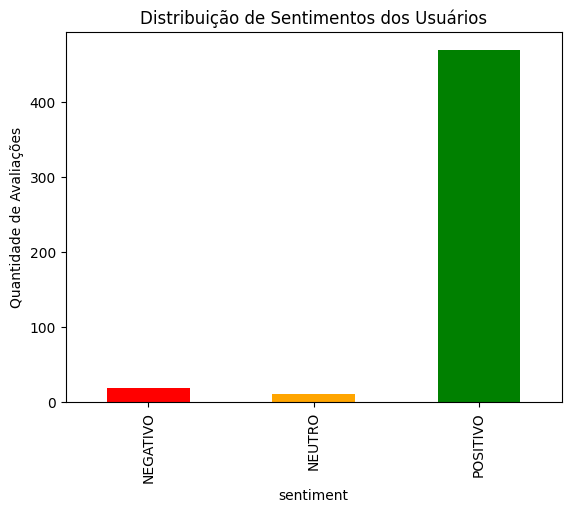

In [12]:
import matplotlib.pyplot as plt

# Ler o resultado final
df_analysis = pd.read_parquet('data_lake/gold/daily_sentiment_summary.parquet')

# Exibir as primeiras linhas da tabela final
print("\n--- TABELA DISPONÍVEL NA CAMADA GOLD ---")
print(df_analysis.head())

# Um plot simples para visualizarmos a distribuição de sentimentos
df_analysis.groupby('sentiment')['total_reviews'].sum().plot(kind='bar', color=['red', 'orange', 'green'])
plt.title('Distribuição de Sentimentos dos Usuários')
plt.ylabel('Quantidade de Avaliações')
plt.show()